In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("youtube_ad_revenue_dataset_clean.csv")

In [3]:
#Engagement rate
df["engagement_rate"] = (df["likes"] + df["comments"]) / df["views"]

In [4]:
#watchtime per view
df["watch_per_view"] = df["watch_time_minutes"] / df["views"]

In [5]:
#view per minute
df["views_per_minute"] = df["views"] / df["video_length_minutes"]

In [6]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate,watch_per_view,views_per_minute
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.155093,2.666789,3471.532423
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.098632,1.518393,421.980413
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.214519,5.678187,385.372360
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.142814,3.122834,852.481742
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.236121,1.584151,1490.237760


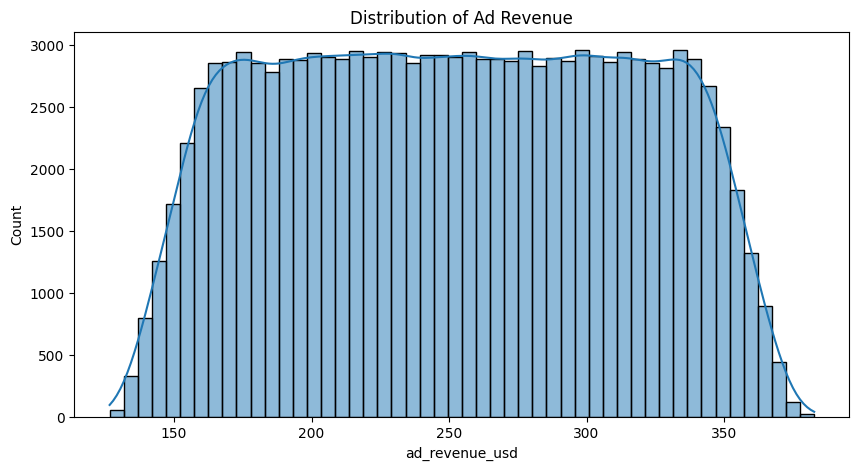

In [ ]:
# Revenue Distribution Histogram

plt.figure(figsize=(10,5))

sns.histplot(df["ad_revenue_usd"], bins=50, kde=True)

plt.title("Distribution of Ad Revenue")

plt.show()

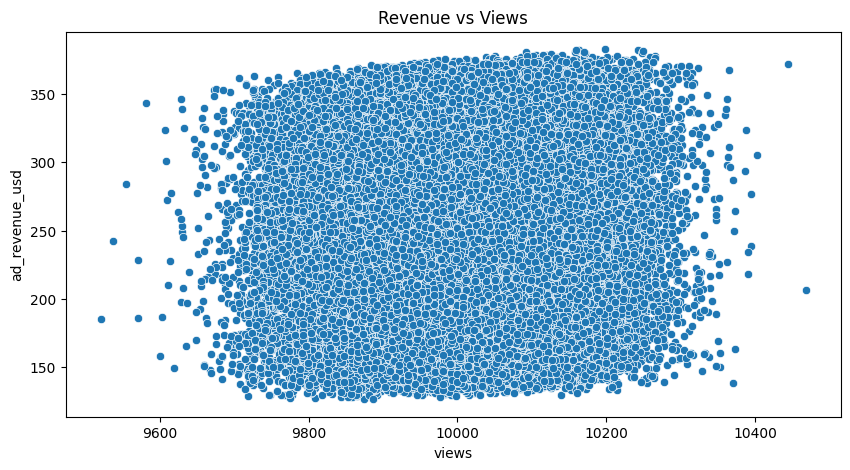

In [13]:
# Revenue vs Views Scatter Plot

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df["views"],
    y=df["ad_revenue_usd"]
)

plt.title("Revenue vs Views")

plt.show()

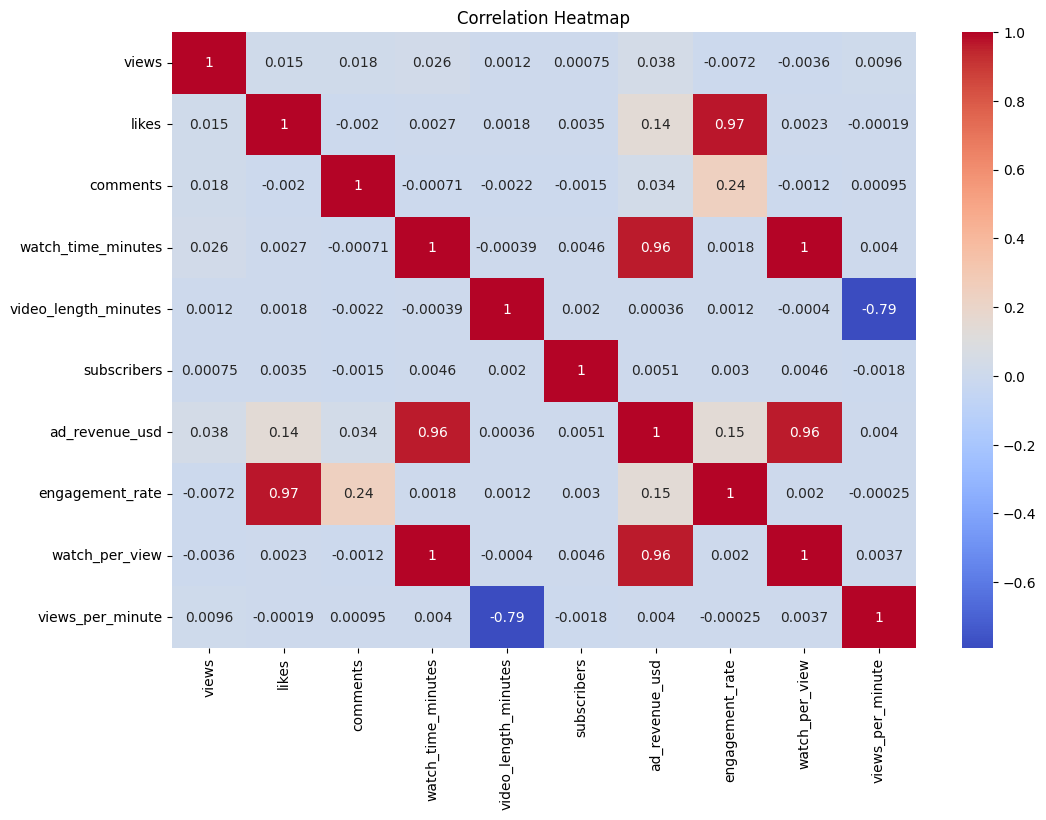

In [18]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

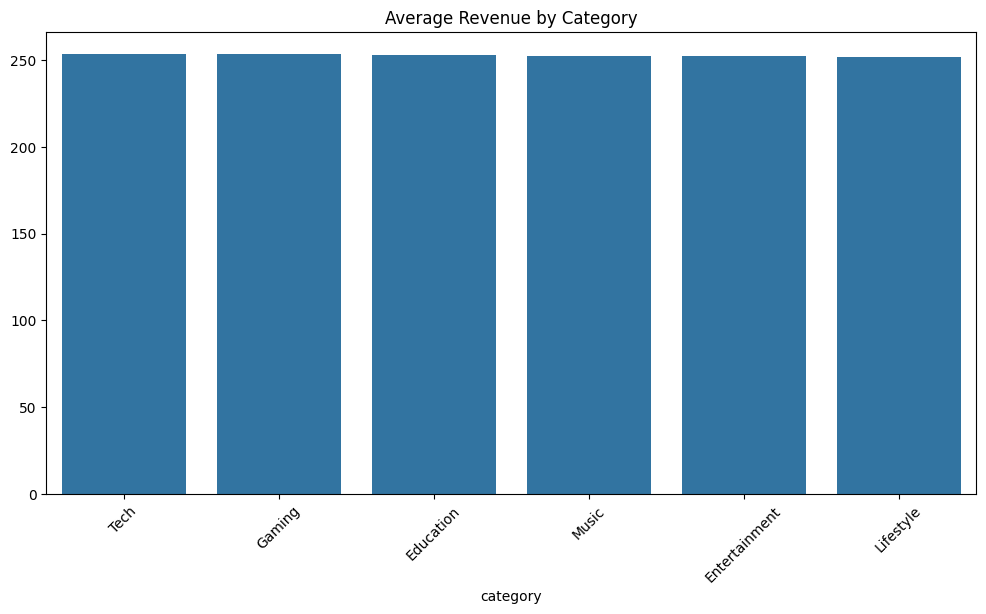

In [15]:
# Revenue by Category

plt.figure(figsize=(12,6))

avg_cat = (
    df.groupby("category")["ad_revenue_usd"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=avg_cat.index,
    y=avg_cat.values
)

plt.xticks(rotation=45)

plt.title("Average Revenue by Category")

plt.show()

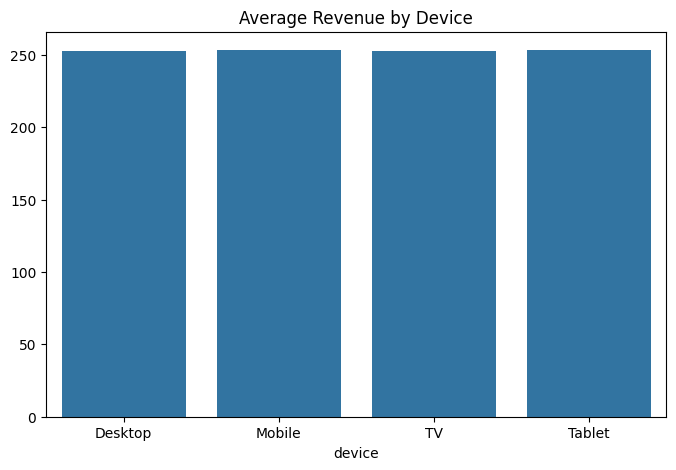

In [11]:
#Revenue by Device

plt.figure(figsize=(8,5))

avg_device = (
    df.groupby("device")["ad_revenue_usd"]
    .mean()
)

sns.barplot(
    x=avg_device.index,
    y=avg_device.values
)

plt.title("Average Revenue by Device")

plt.show()

In [19]:
df.to_csv("youtube_ad_revenue_dataset_featured.csv", index=False)

### Key Findings
- Views strongly influence ad revenue
- Engagement positively impacts monetization
- Watch time contributes to higher revenue
- Certain content categories monetize better
- Device type shows revenue variation